In [1]:
import numpy as np
from matplotlib import pyplot as plt 

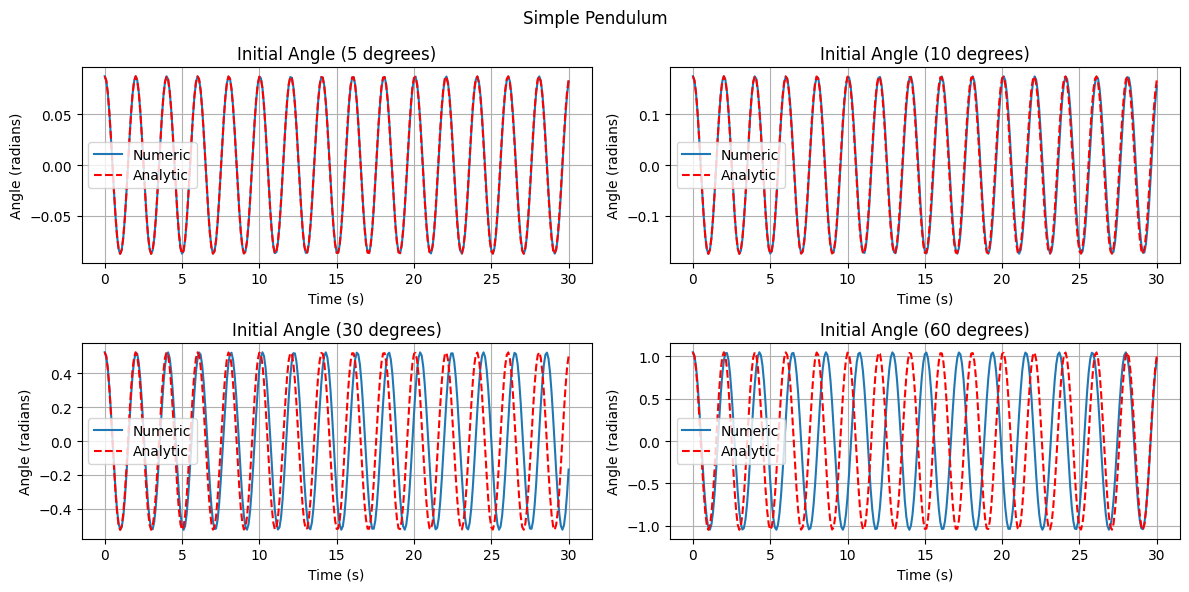

In [2]:
# Define the nonlinear equation of motion of the simple pendulum
def ode(t, state):
    theta = state[0]
    omega = state[1]
    alpha = -g/L * np.sin(theta)

    return np.array([omega, alpha])


# Define the RK4 method
def rk4(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + 1/2 * h, y + 1/2 * h * k1)
    k3 = f(t + 1/2 * h, y + 1/2 * h * k2)
    k4 = f(t + h, y + h * k3)

    y_next = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

    return y_next


# Define the parameters
g = 9.81
L = 1.0
tspan, dt = 30, 0.1
t = np.arange(0, tspan + dt, dt)


# Define initial angular displacements and angular velocities
theta_5, theta_10, theta_30, theta_60 = (
    np.deg2rad(5),
    np.deg2rad(10),
    np.deg2rad(30),
    np.deg2rad(60)
)

omega_5, omega_10, omega_30, omega_60 = 0, 0, 0, 0


# Define the initial state
init_state_5 = np.array([theta_5, omega_5])
init_state_10 = np.array([theta_10, omega_10])
init_state_30 = np.array([theta_30, omega_30])
init_state_60 = np.array([theta_60, omega_60])


state_5 = np.zeros((len(t), 2))
state_10 = np.zeros((len(t), 2))
state_30 = np.zeros((len(t), 2))
state_60 = np.zeros((len(t), 2))


# Set the initial conditions
state_5[0] = init_state_5
state_10[0] = init_state_10
state_30[0] = init_state_30
state_60[0] = init_state_60


# Integrate the nonlinear equations
for i in range(len(t) - 1):
    state_5[i+1] = rk4(ode, t[i], state_5[i], dt)
    state_10[i+1] = rk4(ode, t[i], state_10[i], dt)
    state_30[i+1] = rk4(ode, t[i], state_30[i], dt)
    state_60[i+1] = rk4(ode, t[i], state_60[i], dt)


# Calculate the analytical solutions
theta_analytic_5 = theta_5 * np.cos(np.sqrt(g/L) * t)
theta_analytic_10 = theta_10 * np.cos(np.sqrt(g/L) * t)
theta_analytic_30 = theta_30 * np.cos(np.sqrt(g/L) * t)
theta_analytic_60 = theta_60 * np.cos(np.sqrt(g/L) * t)


theta_5_plot = state_5[:, 0]
theta_10_plot = state_10[:, 0]
theta_30_plot = state_30[:, 0]
theta_60_plot = state_60[:, 0]


# Plot numerical and analytical solutions for each initial angle
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
plt.suptitle('Simple Pendulum')


# Initial angle: 5 degrees
ax[0, 0].plot(t, theta_5_plot, label='Numeric')
ax[0, 0].plot(t, theta_analytic_5, 'r--', label='Analytic')
ax[0, 0].set_title('Initial Angle (5 degrees)')
ax[0, 0].set_xlabel('Time (s)')
ax[0, 0].set_ylabel('Angle (radians)')
ax[0, 0].grid()
ax[0, 0].legend()


# Initial angle: 10 degrees
ax[0, 1].plot(t, theta_10_plot, label='Numeric')
ax[0, 1].plot(t, theta_analytic_10, 'r--', label='Analytic')
ax[0, 1].set_title('Initial Angle (10 degrees)')
ax[0, 1].set_xlabel('Time (s)')
ax[0, 1].set_ylabel('Angle (radians)')
ax[0, 1].grid()
ax[0, 1].legend()


# Initial angle: 30 degrees
ax[1, 0].plot(t, theta_30_plot, label='Numeric')
ax[1, 0].plot(t, theta_analytic_30, 'r--', label='Analytic')
ax[1, 0].set_title('Initial Angle (30 degrees)')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Angle (radians)')
ax[1, 0].grid()
ax[1, 0].legend()


# Initial angle: 60 degrees
ax[1, 1].plot(t, theta_60_plot, label='Numeric')
ax[1, 1].plot(t, theta_analytic_60, 'r--', label='Analytic')
ax[1, 1].set_title('Initial Angle (60 degrees)')
ax[1, 1].set_xlabel('Time (s)')
ax[1, 1].set_ylabel('Angle (radians)')
ax[1, 1].grid()
ax[1, 1].legend()


plt.tight_layout()
plt.show()